In [37]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client.session')

# Web scraping the data
import requests
from bs4 import BeautifulSoup
import pandas as pd

### Data Acquisition: Web Scraping Airline Reviews

This section initiates the data collection process by web scraping customer reviews for British Airways from AirlineQuality.com. The goal is to gather a substantial dataset of unstructured text data for subsequent Natural Language Processing (NLP) tasks. The `requests` library is used to fetch web page content, and `BeautifulSoup` is employed for parsing the HTML to extract the relevant review text.

In [38]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        # clean the data
        # "✅ Trip Verified |" removing mentions of verified/ not verified so that results from sentiment analysis are nt affected
        stripped = para.get_text().split("|",1)
        reviews.append(stripped[1])

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


### Structuring the Scraped Data

After collecting 1000 reviews, the unstructured text data is organized into a Pandas DataFrame. Each row represents a single customer review. This structured format is essential for applying further text preprocessing and analytical techniques. Displaying the head of the DataFrame allows for an initial inspection of the data format.

In [39]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,Although the staff on board the flight wer...
1,I recently flew British Airways from LHR to...
2,T5 lounge fairly good. We got bulkhead seat...
3,Check in was efficient. Lounge was good wit...
4,First and last time flying with BA. A bad e...


### Initial Data Storage

The collected and structured reviews are saved to a CSV file named `BA_reviews.csv`. This step ensures data persistence and allows for easy reloading of the dataset without needing to repeat the web scraping process, which is beneficial for reproducibility and iterative development.

In [40]:
df.to_csv("BA_reviews.csv")

### Text Preprocessing: Punctuation Removal

To prepare the text data for topic modeling and sentiment analysis, punctuation is removed. This step is crucial because punctuation marks can introduce noise and interfere with word-based analyses. A custom function `removePunctuation` is applied to the 'reviews' column of the DataFrame. The cleaned data is then saved back to the CSV file.

In [41]:
# Understanding the data using topic modelling, word clouds and sentiment analysis
import string

def removePunctuation(text):
  translator = str.maketrans('', '', string.punctuation)
  return text.translate(translator)

df['reviews'] = df['reviews'].apply(removePunctuation)
df.to_csv("BA_reviews.csv")

### Exploratory Text Analysis: Word Cloud Generation

To gain an initial understanding of the most frequently used words in the reviews, a word cloud is generated. This visualization technique highlights words that appear more often, providing quick insights into the dominant themes and keywords mentioned by customers. Before generating the word cloud, the number of unique words is calculated to inform the `max_words` parameter for better visual representation. The word cloud offers a compelling visual summary of the corpus content.

9728


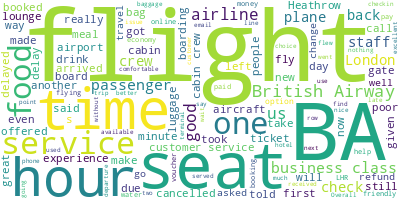

In [42]:
from wordcloud import WordCloud

# Checking the number of unique words

words = df['reviews'].str.split()

# Flatten the list of words into a single list
allWords = [word for sublist in words for word in sublist]

uniqueWords = pd.Series(allWords).unique()
numUniqueWords = len(uniqueWords)
print(numUniqueWords)

# Generating word cloud
allReviews = ','.join(list(df['reviews'].values))

wordcloud = WordCloud(background_color="white", max_words=9283, contour_width=3, contour_color='steelblue')
wordcloud.generate(allReviews)
wordcloud.to_image()

### Text Preprocessing for LDA: Tokenization and Stopword Removal

Before applying LDA, further text preprocessing is performed:
1.  **Tokenization:** Reviews are broken down into individual words (tokens) using `gensim.utils.simple_preprocess`.
2.  **Stopword Removal:** Common English stopwords (e.g., 'the', 'is', 'and') are removed, along with additional domain-specific words ('from', 'subject', 're', 'edu', 'use'), as these words carry little semantic meaning and can obscure meaningful topics.

These steps are essential to reduce dimensionality and ensure that the topic model focuses on significant terms.

In [43]:
# Topic modelling using LDA

import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stopWords = stopwords.words('english')
stopWords.extend(['from', 'subject', 're', 'edu', 'use'])

def sentToWords(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def removeStopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stopWords] for doc in texts]

data = df.reviews.values.tolist()
dataWords = list(sentToWords(data))

dataWords = removeStopwords(dataWords)
print(dataWords[:1][0][:100])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['although', 'staff', 'board', 'flight', 'lovely', 'plane', 'old', 'tired', 'paid', 'extra', 'leg', 'room', 'seats', 'fly', 'new', 'york', 'seats', 'cheap', 'soon', 'found', 'screen', 'completely', 'unusable', 'sound', 'muffled', 'squeak', 'informed', 'staff', 'also', 'problems', 'screens', 'board', 'restarting', 'tried', 'different', 'earphones', 'sound', 'still', 'staff', 'couldnt', 'fix', 'left', 'long', 'flight', 'new', 'york', 'paid', 'extra', 'without', 'flight', 'entertainment', 'returned', 'home', 'contacted', 'customer', 'services', 'complain', 'offered', 'next', 'flight', 'within', 'year', 'informed', 'wont', 'booking', 'flights', 'gave', 'options', 'think', 'completely', 'unacceptable', 'considering', 'cost', 'tickets', 'definitely', 'flying']


### Preparing Corpus for LDA

This section converts the preprocessed text data into a format suitable for Gensim's LDA model.
1.  **Dictionary Creation:** A dictionary (`idx2word`) is created, mapping each unique word to a numerical ID.
2.  **Corpus Creation (Term Document Frequency):** Each review is converted into a bag-of-words representation, where each document (review) is represented as a list of `(word_id, word_count)` tuples. This numerical representation, known as Term Document Frequency, is the standard input for LDA models.

In [44]:
import gensim.corpora as corpora

# Dictionary
idx2word = corpora.Dictionary(dataWords)
# Corpus
texts = dataWords
# Term Document Frequency
corpus = [idx2word.doc2bow(text) for text in texts]

print(corpus[:1][0][:30])


[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 2), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 2), (17, 1), (18, 4), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 2), (26, 1), (27, 1), (28, 1), (29, 1)]


### Latent Dirichlet Allocation (LDA) Model Training

Here, the LDA model is trained on the prepared corpus. LDA is a generative statistical model that explains sets of observations by unobserved groups that explain why some parts of the data are similar. In this context, it identifies 'topics' that are latent in the collection of airline reviews.

The `numTopics` variable is set to 10, meaning the model will attempt to find 10 distinct underlying themes. The `ldaModel.print_topics()` output shows the most significant keywords associated with each identified topic, providing a preliminary interpretation of what each topic represents.

In [45]:
# Training the LDA model
from pprint import pprint

numTopics = 10

ldaModel = gensim.models.LdaMulticore(corpus=corpus, id2word=idx2word, num_topics=numTopics)

pprint(ldaModel.print_topics())
docLda = ldaModel[corpus]

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=6624) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


[(0,
  '0.023*"ba" + 0.016*"flight" + 0.013*"service" + 0.007*"one" + 0.006*"good" '
  '+ 0.006*"seat" + 0.006*"airways" + 0.006*"get" + 0.005*"food" + '
  '0.005*"time"'),
 (1,
  '0.017*"flight" + 0.014*"ba" + 0.007*"british" + 0.006*"airways" + '
  '0.006*"london" + 0.005*"time" + 0.005*"us" + 0.005*"staff" + 0.005*"seats" '
  '+ 0.005*"service"'),
 (2,
  '0.023*"flight" + 0.017*"ba" + 0.008*"time" + 0.007*"service" + '
  '0.006*"would" + 0.006*"experience" + 0.006*"food" + 0.005*"cabin" + '
  '0.005*"hours" + 0.004*"seat"'),
 (3,
  '0.029*"flight" + 0.015*"ba" + 0.011*"seat" + 0.009*"seats" + '
  '0.009*"service" + 0.008*"business" + 0.006*"staff" + 0.006*"food" + '
  '0.006*"class" + 0.006*"crew"'),
 (4,
  '0.024*"flight" + 0.013*"ba" + 0.008*"time" + 0.007*"service" + 0.006*"food" '
  '+ 0.006*"us" + 0.006*"london" + 0.006*"passengers" + 0.006*"staff" + '
  '0.006*"cabin"'),
 (5,
  '0.021*"ba" + 0.020*"flight" + 0.010*"good" + 0.010*"service" + 0.008*"time" '
  '+ 0.006*"staff" + 

### Visualizing LDA Topics with pyLDAvis

After training the LDA model, `pyLDAvis` is used to create an interactive visualization of the discovered topics. This visualization helps in:
*   **Interpreting Topics:** Understanding what each topic is about by examining its most relevant words.
*   **Assessing Topic Coherence:** Evaluating how well-defined and distinct the topics are.
*   **Identifying Overlapping Topics:** Detecting topics that might be too similar and could potentially be merged or re-evaluated.

The `LDAvis_prepared` object is generated and saved as an HTML file for easy sharing and interactive exploration, which is an excellent addition to a portfolio for demonstrating topic modeling capabilities.

In [46]:
# Analysing the results from the LDA model
import pyLDAvis.gensim
import pickle
import pyLDAvis
import os

pyLDAvis.enable_notebook()
LDAvis_data_filepath = os.path.join('ldavis_prepared_'+str(numTopics))

if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(ldaModel, corpus, idx2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)
# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)
pyLDAvis.save_html(LDAvis_prepared, 'ldavis_prepared_'+ str(numTopics) +'.html')
LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.017765  0.007301       1        1  25.983796
7     -0.014270  0.010035       2        1  16.108609
3     -0.007523 -0.020655       3        1  10.262548
5      0.000444 -0.008844       4        1   9.099246
0      0.000115 -0.001240       5        1   8.999633
4     -0.003775  0.003268       6        1   8.141233
2     -0.007298  0.007706       7        1   7.771968
9     -0.000007 -0.028595       8        1   7.328059
1     -0.003863  0.025664       9        1   5.124310
6      0.053942  0.005360      10        1   1.180598, topic_info=         Term         Freq        Total Category  logprob  loglift
18     flight  1854.000000  1854.000000  Default  30.0000  30.0000
154        ba  1227.000000  1227.000000  Default  29.0000  29.0000
545   service   642.000000   642.000000  Default  28.0000  28.0000
163     class   395.000000   395.000000  Default  27.0000  27.0000
157  business   359.000000   359.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
68   boarding     2.448535   248.036907  Topic10  -5.9426  -0.1789
110      seat     2.718347   415.544703  Topic10  -5.8381  -0.5904
75       crew     2.736580   461.627761  Topic10  -5.8314  -0.6889
503        us     2.530027   432.532145  Topic10  -5.9099  -0.7023
288      back     2.307681   288.685033  Topic10  -6.0018  -0.3899

[817 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
1882      2  0.524363      abc
2345      1  0.513627  account
2345      2  0.102725  account
2345      3  0.051363  account
2345      4  0.051363  account
...     ...       ...      ...
61        4  0.328084     york
61        6  0.082021     york
61        7  0.082021     york
61        8  0.082021     york
61        9  0.082021     york

[1951 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 8, 4, 6, 1, 5, 3, 10, 2, 7])

### Sentiment Analysis using TextBlob

Sentiment analysis is performed on each review using the `TextBlob` library. `TextBlob` provides a simple API for common natural language processing (NLP) tasks, including sentiment analysis. For each review, a 'polarity' score is calculated, which is a float within the range [-1.0, 1.0], where -1.0 indicates a negative sentiment and 1.0 indicates a positive sentiment. This score quantifies the emotional tone of the reviews.

In [47]:
# Performing sentiment analysis on reviews
from textblob import TextBlob

def getSentiment(text):
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity
    return sentiment

df['polarity'] = df['reviews'].apply(getSentiment)
df.head(6)

,reviews,polarity
0,Although the staff on board the flight wer...,0.097624
1,I recently flew British Airways from LHR to...,0.032500
2,T5 lounge fairly good We got bulkhead seats...,0.294444
3,Check in was efficient Lounge was good with...,0.304545
4,First and last time flying with BA A bad ex...,-0.122487
5,I am close to retaining Bronze status for the...,-0.023810


### Visualizing Sentiment Distribution

To summarize the sentiment analysis results, the polarity scores are categorized into 'Positive', 'Neutral', and 'Negative' based on their values. A bar plot is then generated to visualize the count of reviews falling into each sentiment category. This plot provides an immediate overview of the overall customer satisfaction (or dissatisfaction) with British Airways based on the collected reviews. The `value_counts()` function also quantifies these categories.

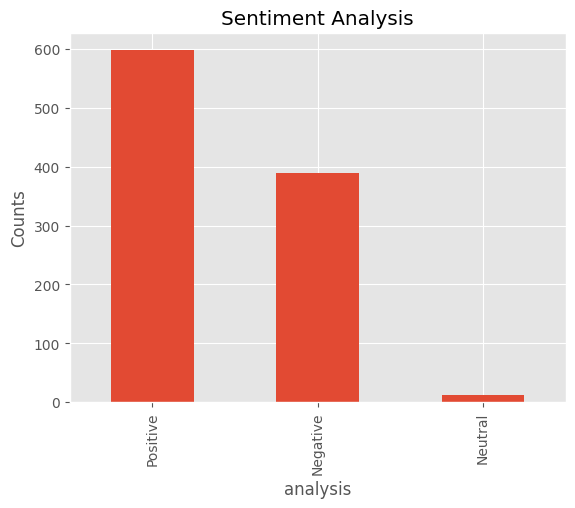

In [48]:
# Plot graph of number of positive and negative reviews
import matplotlib.pyplot as plt

plt.style.use('ggplot')

def getAnalysis(score):
  if score < 0:
    return 'Negative'
  elif score == 0:
    return 'Neutral'
  else:
    return 'Positive'

df['analysis'] = df['polarity'].apply(getAnalysis)

df['analysis'].value_counts()

plt.title('Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Counts')
df['analysis'].value_counts().plot(kind='bar')
plt.show()

### Quantifying Positive Reviews

This cell calculates and displays the percentage of reviews categorized as 'Positive'. This metric provides a concise summary of the proportion of satisfied customers, offering a key performance indicator derived from the sentiment analysis. A high percentage of positive reviews is generally indicative of good customer experience.

In [49]:
pReviews = df[df.analysis == 'Positive']
pReviews = pReviews['reviews']

round( (pReviews.shape[0] / df.shape[0]) *100, 1)

59.8

### Quantifying Negative Reviews

Similarly, this cell calculates and displays the percentage of reviews categorized as 'Negative'. This metric is crucial for identifying areas where customer experience might be lacking. A significant percentage of negative reviews can highlight potential issues that British Airways might need to address to improve customer satisfaction.

In [50]:
nReviews = df[df.analysis == 'Negative']
nReviews = nReviews['reviews']

round( (nReviews.shape[0] / df.shape[0]) *100, 1)

39.0

### Finalizing Sentiment Data Storage

After conducting the sentiment analysis and adding the 'polarity' and 'analysis' columns to the DataFrame, the updated DataFrame is saved back to `BA_reviews.csv`. This ensures that all the derived sentiment information is persistently stored with the original review data, making it readily available for future analysis or reporting.

In [51]:
df.to_csv("BA_reviews.csv")